# Calibrate an objective pair

Measure the focus (parfocality) and XY (parcentricity) offsets between a reference and target objective. Complete the limits and orientation setup first.

## Configure

Edit the session ID and reference slot below. During the run:

- Select the Navigator Expert job once and keep it selected.
- Switch only the objective when instructed.
- Keep XY scan-galvo and z-galvo settings unchanged.
- Use the same physical pixel size (µm/pixel) for both XY images.

In [1]:
import _bootstrap
from navigator_expert.calibration.core import adopt, objective_pair

session = objective_pair.start_session(
    acquisition_name="10x-20x",
    session_id="2026-07-14_calibration_1",
    reference_slot=1,
)

Using active Navigator Expert job: Overview
Configured reference objective: slot 1 — HC PL APO CS2    10x/0.40 DRY


## 1. Reference focus

Switch to the reference objective, focus it, configure its z-stack, and run. 

This works well with a field of view that contains roughly 100 nuclei stained with DAPI.

IMPORTANT: 
- Use a format of 1024 x 1024, and zoom that can give you a pixel size that can also be attaind for the target objetive (e.g. 10x has zoom 2x, and 20x has zoom 1x).
- Make sure that the z-galvo is 0, and that you have selected the Z-wide value where you sample is in focus. 
- Make sure the the "Set Focus" is deselected.
- Setup a Z-stack. Do not use the "System Optimized" settings, but select for "Number of Steps" 80um and for "Z-step Size" 1um
- Pick a laser power this is sufficiently strong (e.g. 10%)



Reference objective: slot 1 — HC PL APO CS2    10x/0.40 DRY


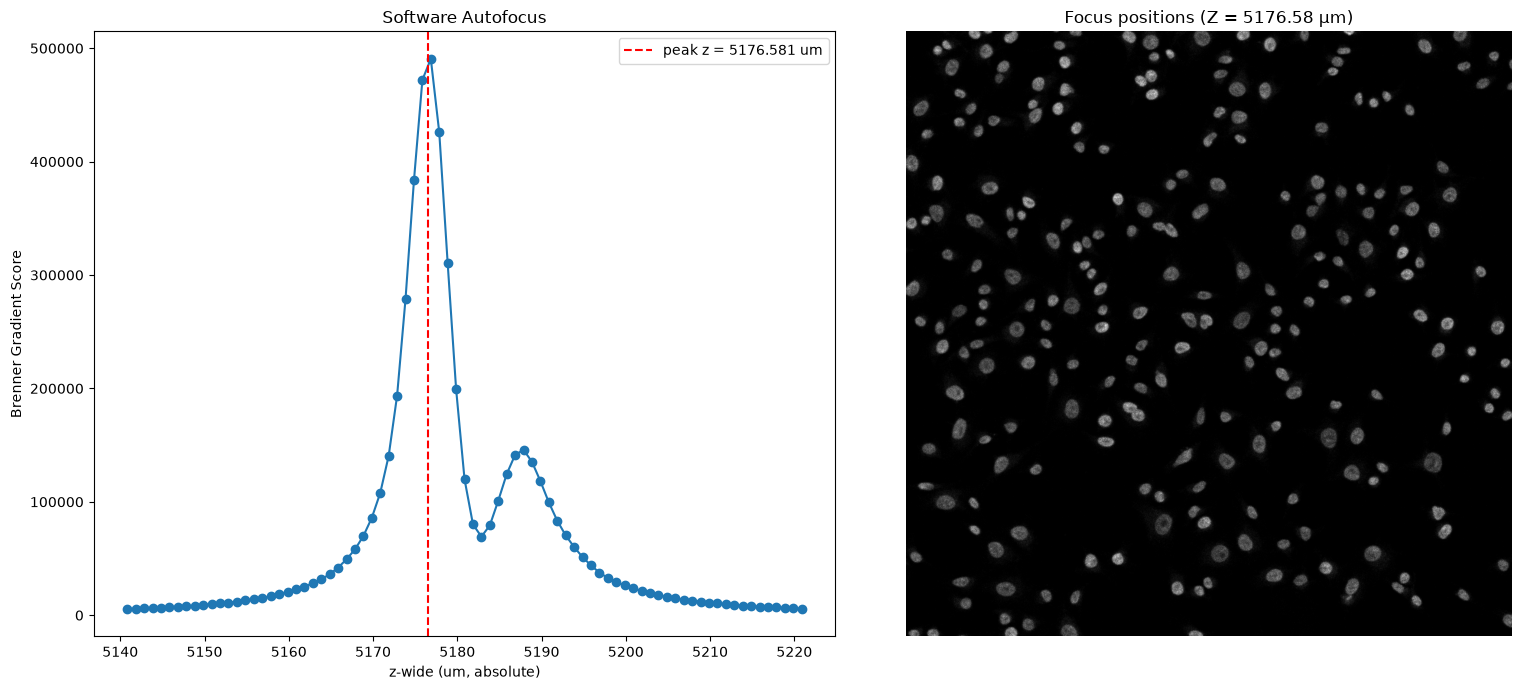

In [2]:
objective_pair.measure(session)

## 2. Target focus

Measure the focus position of the target objective

IMPORTANT
- Do not switch jobs, Do NOT adjust the z-wide position, do NOT adjuste the z-galvo position.
- Switch the objective to the target objective.
- Adjuste the zoom so you arrive to the same pixel size as used in the reference objective
- Do NOT adjust any other settings.

Target objective: slot 2 — HC PL APO CS2    20x/0.75 DRY


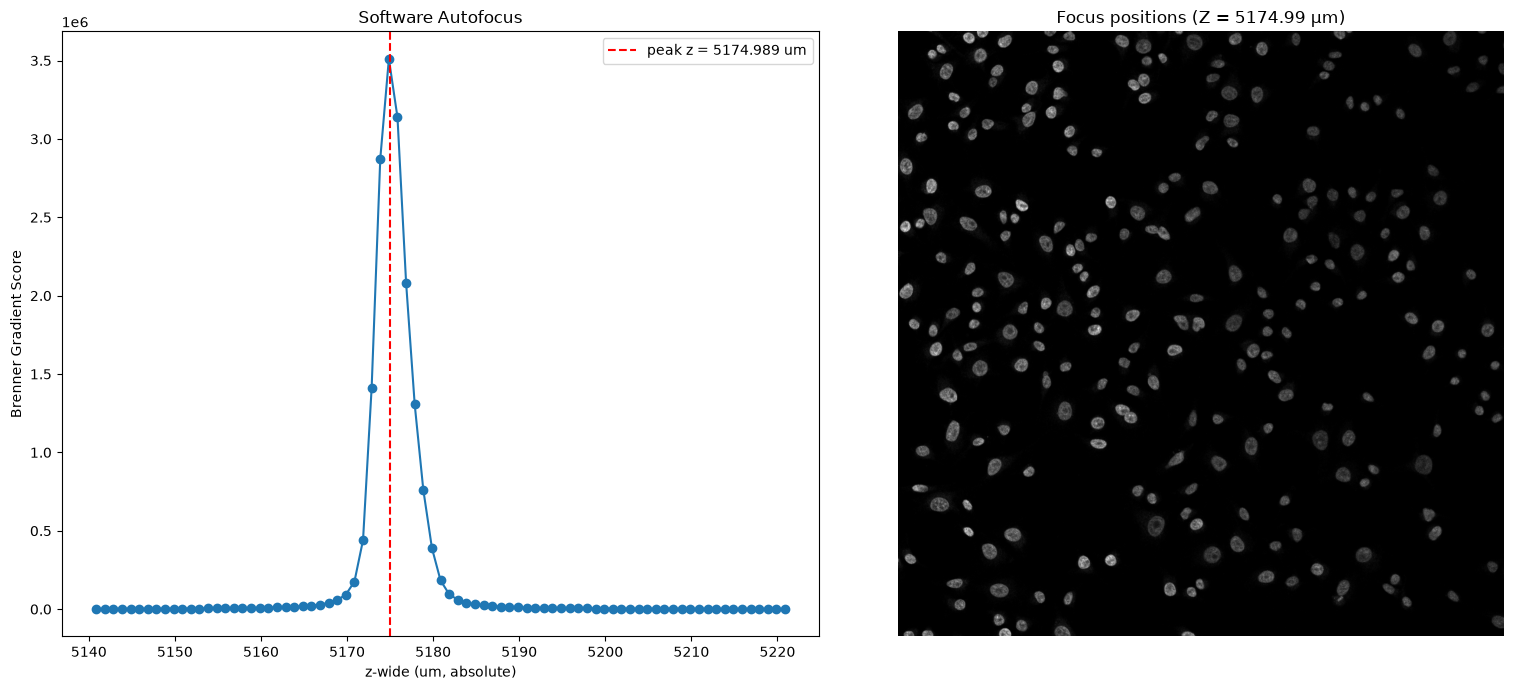

Z-wide translation from HC PL APO CS2    10x/0.40 DRY to HC PL APO CS2    20x/0.75 DRY: -1.59 µm


In [3]:
objective_pair.measure(session)

## 3. Reference XY

Switch back to the reference objective.

IMPORTANT:
- Chose a pixel-size that works for both the reference and target objective
- The pixe-size should be blow 1um and the Format should be at least 1024 x 1024
- Use the same Job 
- Remove the setting for aquiring a z-stack
- Make sure the Z-galvo is 0
- Make sure the Z-wide is selected

In [ ]:
objective_pair.measure(session)

## 4. Target XY

Switch only to the target objective. Do not move motoric XY. Match the reference image's physical pixel size exactly, then run.

In [ ]:
summary = objective_pair.measure(session)

## Adopt

Review the summary and overlay. Adopt only when they look correct.

In [ ]:
adopt.adopt_calibration(
    session,
    notebook_paths=[_bootstrap.NOTEBOOK_PATH],
)

## Optional validation

Park on a textured area with the reference objective, focus, and run the next cell. Then switch only to the target objective and run the final cell. The report shows the residual offset after applying the adopted calibration.

In [ ]:
from navigator_expert.calibration.core import calibration_check

check_session = calibration_check.start_session(
    acquisition_name=session.acquisition_name,
    session_id=session.session_id,
)
_ = calibration_check.measure_reference(check_session)

Switch only to the target objective, keep the same job selected, and run.

In [ ]:
calibration_check.measure_target_and_report(check_session)